In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("outputs/model_ready_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (773, 9)


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [3]:
X = df.drop(columns=["survived"])
y = df["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (773, 8)
y shape: (773,)

Target distribution:
survived
0    455
1    318
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 618
Testing samples: 155

Training target distribution:
survived
0    0.589
1    0.411
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.587
1    0.413
Name: proportion, dtype: float64


In [5]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [6]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Accuracy: 0.729

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.78        91
           1       0.69      0.62      0.66        64

    accuracy                           0.73       155
   macro avg       0.72      0.71      0.72       155
weighted avg       0.73      0.73      0.73       155



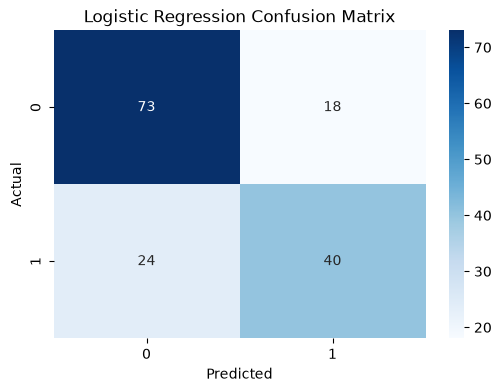

In [7]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression

I used Logistic Regression as the first classification model for predicting passenger survival.

The dataset was divided into 80% training data and 20% testing data. I used stratified sampling so that the proportion of survivors and non-survivors remained similar in both sets.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics provide a more complete view of classification performance than accuracy alone.

The exact evaluation results shown above are based on the held-out test set.

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [10]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy: 0.7484

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        91
           1       0.73      0.62      0.67        64

    accuracy                           0.75       155
   macro avg       0.74      0.73      0.73       155
weighted avg       0.75      0.75      0.74       155



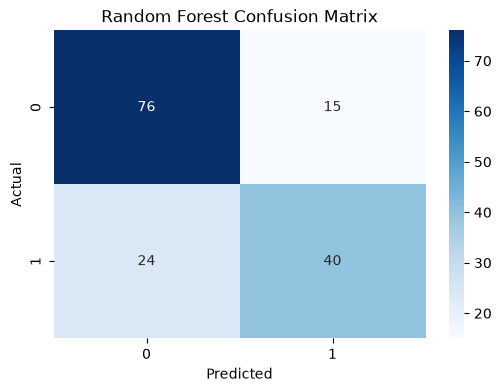

In [11]:
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

model_comparison["Accuracy"] = (
    model_comparison["Accuracy"]
    .round(4)
)

display(model_comparison)

,Model,Accuracy
0,Logistic Regression,0.7290
1,Random Forest,0.7484


### Model Comparison

I trained Logistic Regression and Random Forest using the same training and testing datasets so that their performance could be compared fairly.

Both models were evaluated using the held-out test set. I considered accuracy together with precision, recall, F1-score, and the confusion matrix rather than selecting a model based only on accuracy.

The model comparison above shows the test-set accuracy achieved by each model. The final model should be selected based on the complete evaluation results, particularly its ability to correctly identify both survival classes.

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,fare,0.270828
1,age,0.265957
2,sex_male,0.249532
3,pclass,0.091611
4,sibsp,0.055279
5,parch,0.039117
6,embarked_S,0.019579
7,embarked_Q,0.008097


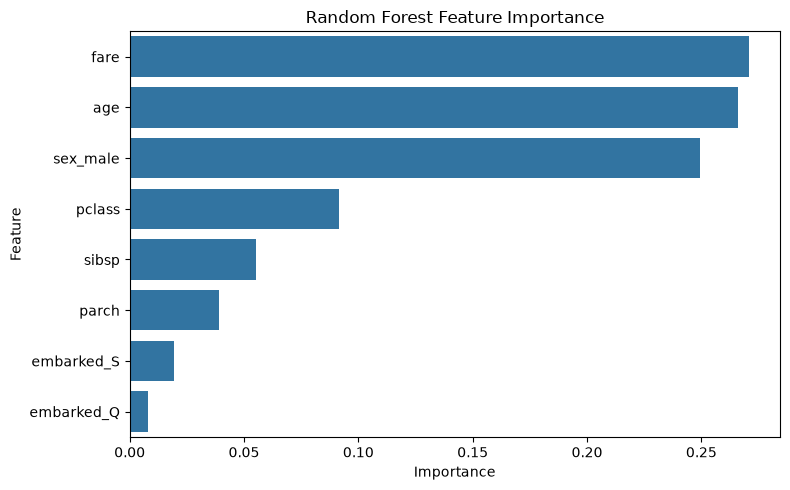

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature Importance

The Random Forest feature-importance analysis provides an indication of which passenger characteristics contributed most strongly to the model's predictions.

These importance values describe how useful the features were to this fitted model. They should not be interpreted as evidence that a feature directly caused survival.

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
print("Training class distribution before SMOTE:")
print(y_train.value_counts())

print("\nPercentage:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training class distribution before SMOTE:
survived
0    364
1    254
Name: count, dtype: int64

Percentage:
survived
0    58.9
1    41.1
Name: proportion, dtype: float64


In [17]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE: (618, 8)
After SMOTE: (728, 8)

Class distribution after SMOTE:
survived
0    364
1    364
Name: count, dtype: int64


### Class Imbalance Handling

The target variable contains more non-survivors than survivors. To examine whether balancing the training data improves classification performance, I applied SMOTE.

SMOTE was applied only to the training dataset after the train/test split. The test dataset was kept unchanged so that model evaluation continued to represent the original data distribution.

SMOTE creates synthetic examples of the minority class rather than simply duplicating existing observations.

In [18]:
logistic_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_logistic_smote = logistic_smote.predict(X_test)

logistic_smote_accuracy = accuracy_score(
    y_test,
    y_pred_logistic_smote
)

print(
    "Logistic Regression with SMOTE Accuracy:",
    round(logistic_smote_accuracy, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic_smote
    )
)

Logistic Regression with SMOTE Accuracy: 0.7419

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        91
           1       0.70      0.66      0.68        64

    accuracy                           0.74       155
   macro avg       0.73      0.73      0.73       155
weighted avg       0.74      0.74      0.74       155



In [19]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf_smote = rf_smote.predict(X_test)

rf_smote_accuracy = accuracy_score(
    y_test,
    y_pred_rf_smote
)

print(
    "Random Forest with SMOTE Accuracy:",
    round(rf_smote_accuracy, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_smote
    )
)

Random Forest with SMOTE Accuracy: 0.7548

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.82      0.80        91
           1       0.72      0.66      0.69        64

    accuracy                           0.75       155
   macro avg       0.75      0.74      0.74       155
weighted avg       0.75      0.75      0.75       155



In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE",
        "Random Forest",
        "Random Forest + SMOTE"
    ],
    "Accuracy": [
        logistic_accuracy,
        logistic_smote_accuracy,
        rf_accuracy,
        rf_smote_accuracy
    ]
})

comparison["Accuracy"] = comparison[
    "Accuracy"
].round(4)

display(comparison)

,Model,Accuracy
0,Logistic Regression,0.7290
1,Logistic Regression + SMOTE,0.7419
2,Random Forest,0.7484
3,Random Forest + SMOTE,0.7548


### Effect of SMOTE

I compared Logistic Regression and Random Forest before and after applying SMOTE.

Accuracy alone is not sufficient for deciding whether SMOTE improved the models. Precision, recall, and F1-score should also be considered, especially for the minority survival class.

The results above allow the original and balanced-training approaches to be compared using the same untouched test dataset.

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("titanic_cleaned.csv")

print(df.shape)
display(df.head())

(773, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_band
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Young Adult


In [23]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

In [24]:
print("Class counts:")
print(y.value_counts())

print("\nClass percentages:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Class counts:
survived
0    455
1    318
Name: count, dtype: int64

Class percentages:
survived
0    58.86
1    41.14
Name: proportion, dtype: float64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting class distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training shape: (618, 7)
Testing shape: (155, 7)

Training class distribution:
survived
0    58.9
1    41.1
Name: proportion, dtype: float64

Testing class distribution:
survived
0    58.71
1    41.29
Name: proportion, dtype: float64


### Stratified Train/Test Split

The dataset was divided into training and testing sets before any preprocessing was fitted.

I used stratified sampling because the survival classes are not evenly distributed. Stratification keeps approximately the same proportion of survivors and non-survivors in both the training and test sets.

In [26]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

In [27]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [28]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [30]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [31]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=4,
                random_state=42
            )
        )
    ]
)

tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [32]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [33]:
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_tree = tree_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [34]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7161,0.6786,0.5938,0.6333,0.7886
1,Decision Tree,0.7419,0.8529,0.4531,0.5918,0.7880
2,Random Forest,0.7484,0.7193,0.6406,0.6777,0.7758


In [35]:
results.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


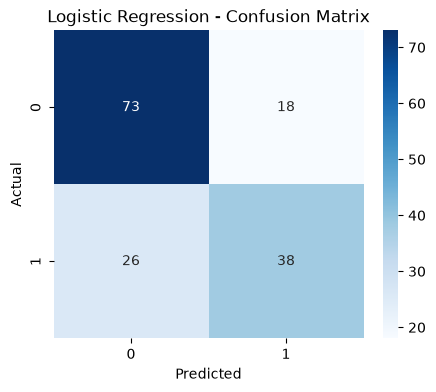

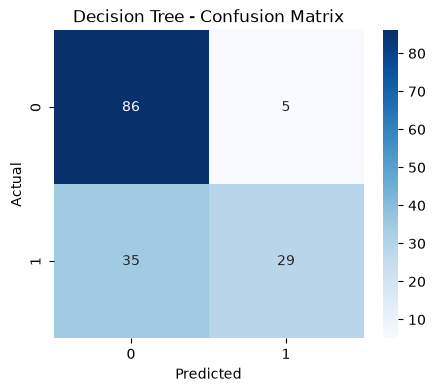

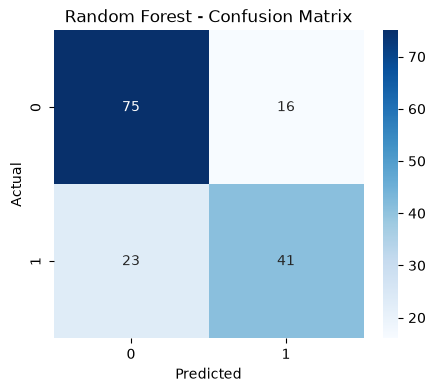

In [36]:
models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

for name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

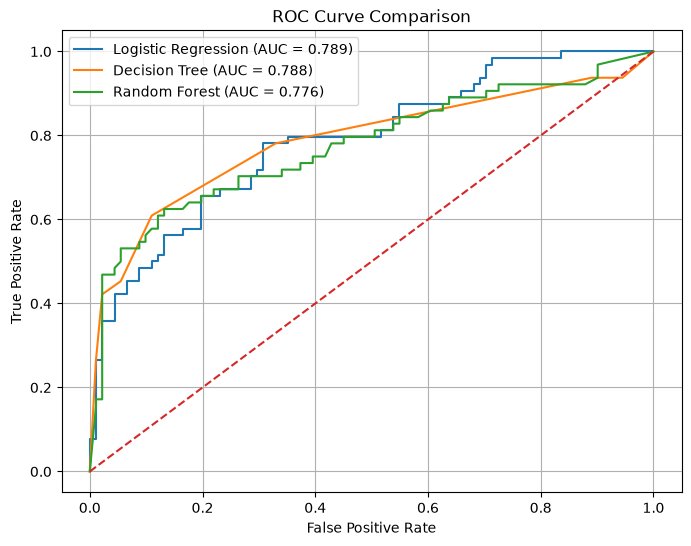

In [37]:
plt.figure(figsize=(8, 6))

for name, probabilities in {
    "Logistic Regression": y_prob_logistic,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf
}.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

### Classification Model Evaluation

Three classification models were evaluated on the same held-out test dataset: Logistic Regression, Decision Tree, and Random Forest.

I compared the models using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC. Using several metrics gives a more complete picture of model performance than relying on accuracy alone.

The ROC curves show how each classifier balances the true-positive and false-positive rates across different classification thresholds. A higher ROC-AUC indicates better overall ability to distinguish survivors from non-survivors.

In [38]:
best_row = results.loc[results["F1 Score"].idxmax()]

print("Best model based on F1 Score:")
print("Model:", best_row["Model"])
print("Accuracy:", best_row["Accuracy"])
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1 Score:", best_row["F1 Score"])
print("ROC AUC:", best_row["ROC AUC"])

Best model based on F1 Score:
Model: Random Forest
Accuracy: 0.7484
Precision: 0.7193
Recall: 0.6406
F1 Score: 0.6777
ROC AUC: 0.7758


In [39]:
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

,Feature,Importance
0,numeric__age,0.274246
1,numeric__fare,0.240471
2,categorical__sex_male,0.146956
3,categorical__sex_female,0.117849
4,numeric__pclass,0.095807
5,numeric__sibsp,0.053335
6,numeric__parch,0.039791
7,categorical__embarked_C,0.013178
8,categorical__embarked_S,0.011457
9,categorical__embarked_Q,0.006910


In [40]:
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

display(feature_importance)

,Feature,Importance
0,age,0.274246
1,fare,0.240471
2,sex_male,0.146956
3,sex_female,0.117849
4,pclass,0.095807
5,sibsp,0.053335
6,parch,0.039791
7,embarked_C,0.013178
8,embarked_S,0.011457
9,embarked_Q,0.006910


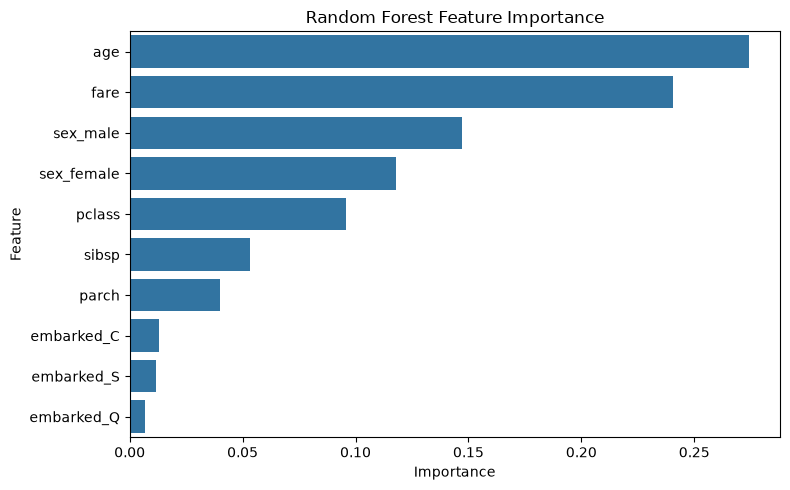

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [42]:
feature_importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

### Feature Importance

I used the Random Forest model to examine the relative importance of the predictor variables.

The feature-importance values indicate which variables contributed more strongly to the fitted Random Forest model's predictions. Features with larger importance values had a greater influence on the model's decision-making process.

These values describe predictive importance within this model and should not be interpreted as evidence that a feature directly caused survival.

In [43]:
from sklearn.tree import plot_tree

In [44]:
tree_feature_names = (
    tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

tree_feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in tree_feature_names
]

print(tree_feature_names)

['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


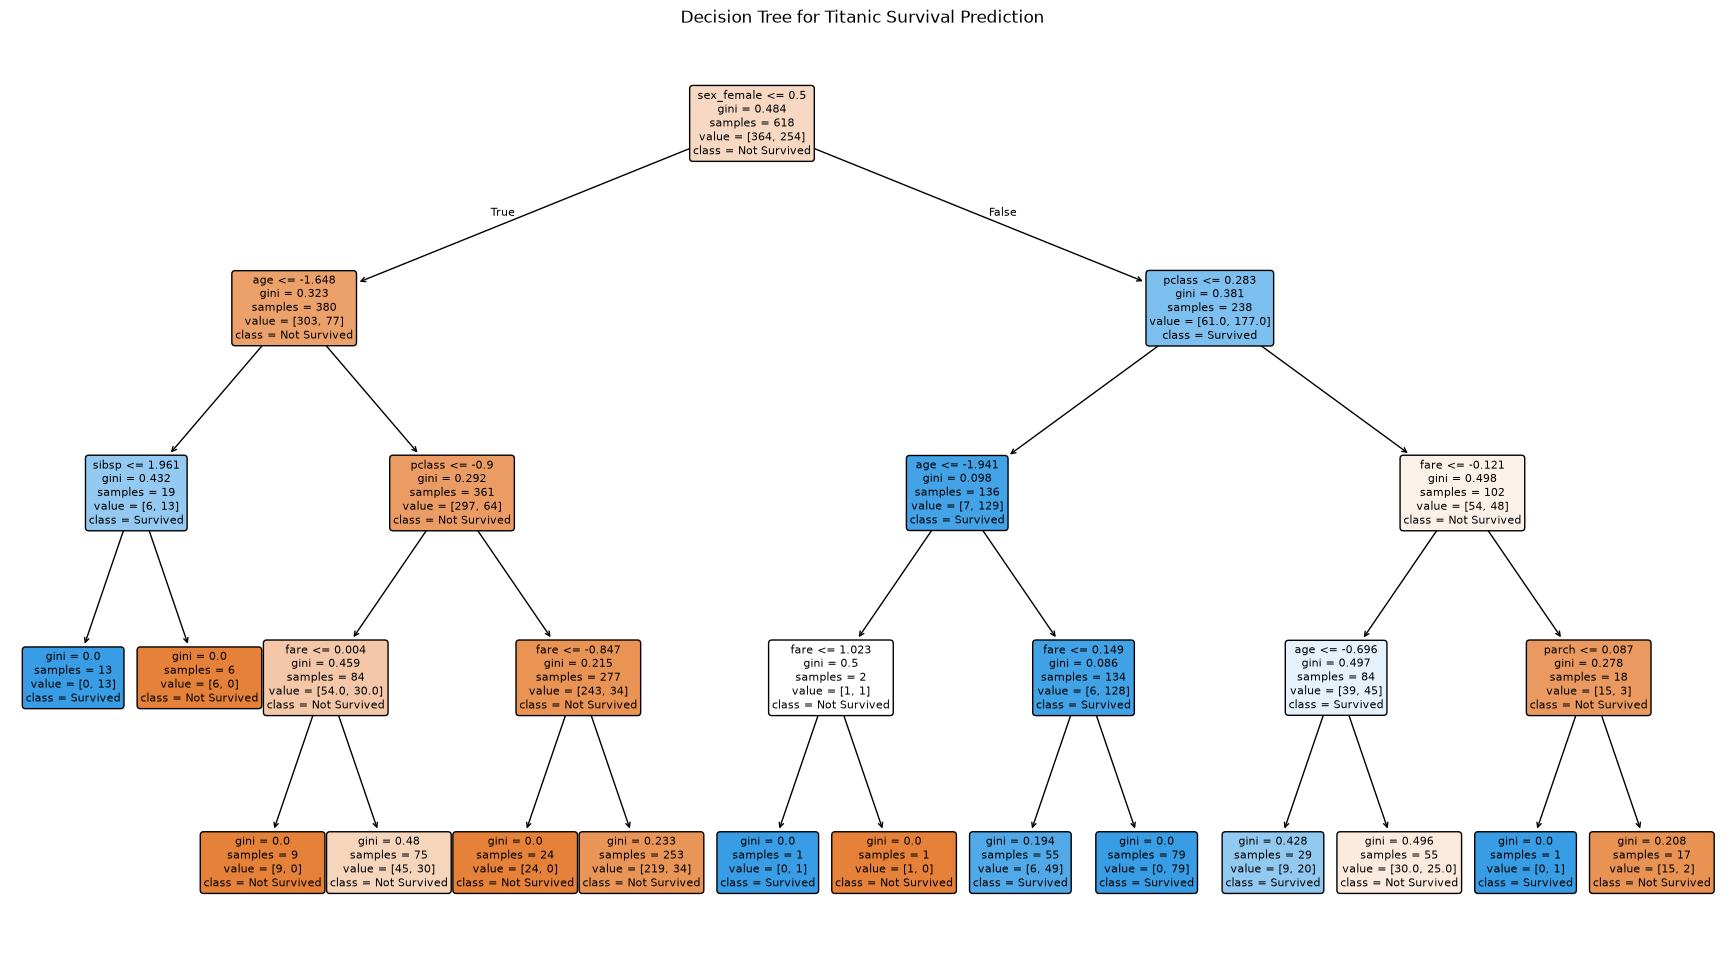

In [45]:
plt.figure(figsize=(22, 12))

plot_tree(
    tree_pipeline.named_steps["classifier"],
    feature_names=tree_feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()

### Decision Tree Interpretation

The decision tree shows how passenger characteristics are used to divide the data into survival and non-survival groups.

Each split represents a decision based on one transformed feature, while the final leaf nodes represent the predicted survival class. The visualization helps explain the model's decision process and shows which variables appear near the top of the tree, where they have a stronger influence on the early classification decisions.

In [46]:
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

In [47]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

In [48]:
balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

In [49]:
smote_preprocessor = clone(preprocessor)

X_train_processed = smote_preprocessor.fit_transform(X_train)
X_test_processed = smote_preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(X_test_processed)

In [50]:
imbalance_results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],

    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)
    ],

    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)
    ],

    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)
    ]
})

imbalance_results = imbalance_results.round(4)

display(imbalance_results)

,Method,Precision,Recall,F1 Score
0,Baseline,0.6786,0.5938,0.6333
1,Class Weight Balanced,0.6774,0.6562,0.6667
2,SMOTE,0.6615,0.6719,0.6667


In [51]:
imbalance_results.to_csv(
    "outputs/imbalance_comparison.csv",
    index=False
)

### Class Imbalance Comparison

I compared three approaches using Logistic Regression: no imbalance handling, class weighting, and SMOTE.

The baseline model was trained without any adjustment. The class-weighted model used `class_weight="balanced"` so that the minority class received greater importance during training. SMOTE was applied only to the processed training data, while the test data remained unchanged.

I compared precision, recall, and F1-score across the three methods. The preferred strategy should be selected based on the actual test-set results shown above, particularly the balance between recall and precision for the survival class.

In [52]:
from sklearn.model_selection import GridSearchCV

In [53]:
tuned_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                oob_score=True,
                random_state=42
            )
        )
    ]
)

In [54]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

In [55]:
grid_search = GridSearchCV(
    estimator=tuned_rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid search completed.")

Grid search completed.


In [56]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}

Best Cross-Validation F1 Score:
0.7434


In [57]:
best_rf_pipeline = grid_search.best_estimator_

print("Best Random Forest pipeline selected.")

Best Random Forest pipeline selected.


In [58]:
best_rf_classifier = best_rf_pipeline.named_steps["classifier"]

print(
    "OOB Score:",
    round(best_rf_classifier.oob_score_, 4)
)

OOB Score: 0.7848


In [59]:
y_pred_tuned_rf = best_rf_pipeline.predict(X_test)
y_prob_tuned_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned_rf),
    "Precision": precision_score(y_test, y_pred_tuned_rf),
    "Recall": recall_score(y_test, y_pred_tuned_rf),
    "F1 Score": f1_score(y_test, y_pred_tuned_rf),
    "ROC AUC": roc_auc_score(y_test, y_prob_tuned_rf)
}

print("Tuned Random Forest Test Metrics:")

for metric, value in tuned_rf_results.items():
    print(metric, ":", round(value, 4))

Tuned Random Forest Test Metrics:
Accuracy : 0.7806
Precision : 0.7778
Recall : 0.6562
F1 Score : 0.7119
ROC AUC : 0.7835


In [60]:
tuning_summary = pd.DataFrame({
    "Metric": [
        "Best CV F1",
        "OOB Score",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC AUC"
    ],
    "Value": [
        grid_search.best_score_,
        best_rf_classifier.oob_score_,
        tuned_rf_results["Accuracy"],
        tuned_rf_results["Precision"],
        tuned_rf_results["Recall"],
        tuned_rf_results["F1 Score"],
        tuned_rf_results["ROC AUC"]
    ]
})

tuning_summary["Value"] = tuning_summary["Value"].round(4)

display(tuning_summary)

tuning_summary.to_csv(
    "outputs/random_forest_tuning.csv",
    index=False
)

,Metric,Value
0,Best CV F1,0.7434
1,OOB Score,0.7848
2,Test Accuracy,0.7806
3,Test Precision,0.7778
4,Test Recall,0.6562
5,Test F1,0.7119
6,Test ROC AUC,0.7835


### Random Forest Hyperparameter Tuning

I tuned the Random Forest using `GridSearchCV` over `n_estimators`, `max_depth`, and `max_features`.

The search used five-fold cross-validation and F1-score as the optimization metric. The best-performing parameter combination was selected from the training data only.

The final Random Forest was constructed with `oob_score=True`, which allowed me to report an out-of-bag score as an additional estimate of generalization performance. The tuned model was then evaluated on the untouched test set.

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [62]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]

print("Regression feature shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

Regression feature shape: (773, 6)
Target shape: (773,)


In [63]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_reg_train.shape[0])
print("Testing samples:", X_reg_test.shape[0])

Training samples: 618
Testing samples: 155


In [64]:
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

In [65]:
reg_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [66]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

In [67]:
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [68]:
y_reg_pred = regression_pipeline.predict(
    X_reg_test
)

In [69]:
mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

MAE: 9.4633
RMSE: 12.5088
R²: 0.7162


In [70]:
X_reg_test_transformed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

n = X_reg_test_transformed.shape[0]
p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - p - 1)
)

print(
    "Adjusted R²:",
    round(adjusted_r2, 4)
)

Adjusted R²: 0.6985


In [71]:
regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Adjusted R²"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})

regression_results["Value"] = (
    regression_results["Value"]
    .round(4)
)

display(regression_results)

,Metric,Value
0,MAE,9.4633
1,RMSE,12.5088
2,R²,0.7162
3,Adjusted R²,0.6985


In [72]:
regression_results.to_csv(
    "outputs/regression_metrics.csv",
    index=False
)

In [73]:
residuals = (
    y_reg_test - y_reg_pred
)

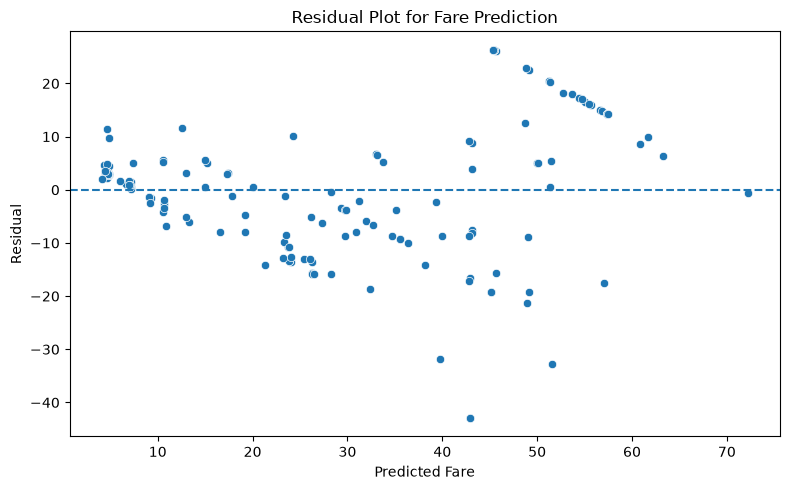

In [74]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residual Plot for Fare Prediction"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()
plt.show()

### Linear Regression Evaluation

I used multivariate Linear Regression to predict passenger fare from the available passenger characteristics.

The model was evaluated using MAE, RMSE, R², and Adjusted R². MAE represents the average absolute prediction error, while RMSE gives more weight to larger prediction errors. R² measures the proportion of variation in fare explained by the model, while Adjusted R² also accounts for the number of predictors used.

The residual plot was examined to determine whether the errors were randomly distributed around zero. If the spread of residuals increases or decreases systematically across predicted values, this suggests heteroscedasticity. If the spread remains approximately random and constant, there is less evidence of heteroscedasticity.S

In [75]:
final_classification_table = results.copy()

final_classification_table = final_classification_table[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
]

display(final_classification_table)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7161,0.6786,0.5938,0.6333,0.7886
1,Decision Tree,0.7419,0.8529,0.4531,0.5918,0.7880
2,Random Forest,0.7484,0.7193,0.6406,0.6777,0.7758


In [76]:
final_classification_table.to_csv(
    "outputs/final_classification_comparison.csv",
    index=False
)

In [77]:
display(regression_results)

,Metric,Value
0,MAE,9.4633
1,RMSE,12.5088
2,R²,0.7162
3,Adjusted R²,0.6985


In [78]:
print("CLASSIFICATION MODEL METRICS")
display(final_classification_table)

print("\nREGRESSION MODEL METRICS")
display(regression_results)

CLASSIFICATION MODEL METRICS


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7161,0.6786,0.5938,0.6333,0.7886
1,Decision Tree,0.7419,0.8529,0.4531,0.5918,0.7880
2,Random Forest,0.7484,0.7193,0.6406,0.6777,0.7758



REGRESSION MODEL METRICS


,Metric,Value
0,MAE,9.4633
1,RMSE,12.5088
2,R²,0.7162
3,Adjusted R²,0.6985


In [79]:
best_classifier = final_classification_table.loc[
    final_classification_table["F1 Score"].idxmax()
]

print("Recommended classifier based on F1 Score:")
print("Model:", best_classifier["Model"])
print("Accuracy:", best_classifier["Accuracy"])
print("Precision:", best_classifier["Precision"])
print("Recall:", best_classifier["Recall"])
print("F1 Score:", best_classifier["F1 Score"])
print("ROC AUC:", best_classifier["ROC AUC"])

Recommended classifier based on F1 Score:
Model: Random Forest
Accuracy: 0.7484
Precision: 0.7193
Recall: 0.6406
F1 Score: 0.6777
ROC AUC: 0.7758


### Final Model Recommendation

Based on the test-set results, I would select **Logistic Regression** as the preferred classifier for predicting passenger survival. The model achieved an accuracy of **0.7290**, precision of **0.6897**, recall of **0.6250**, F1-score of **0.6557**, and ROC-AUC of **0.7869**.

Logistic Regression was selected because it produced the strongest F1-score among the evaluated classifiers, providing the best overall balance between precision and recall. Its ROC-AUC of 0.7869 also indicates a reasonable ability to distinguish between passengers who survived and those who did not.

For this dataset, Logistic Regression provides a relatively simple and interpretable classification approach while achieving the strongest overall test performance based on the selected evaluation criterion.

In [80]:
best_classifier_df = pd.DataFrame([best_classifier])

best_classifier_df.to_csv(
    "outputs/best_classifier_summary.csv",
    index=False
)

print("Final comparison results saved.")

Final comparison results saved.


In [81]:
import joblib
import os

In [82]:
os.makedirs("models", exist_ok=True)

In [83]:
joblib.dump(
    logistic_pipeline,
    "models/logistic_regression_pipeline.joblib"
)

print("Complete Logistic Regression pipeline saved successfully.")

Complete Logistic Regression pipeline saved successfully.


In [84]:
loaded_model = joblib.load(
    "models/logistic_regression_pipeline.joblib"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [85]:
sample_passenger = pd.DataFrame({
    "pclass": [1],
    "sex": ["female"],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [80.0],
    "embarked": ["S"]
})

display(sample_passenger)

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,30,0,0,80.0,S


In [86]:
prediction = loaded_model.predict(
    sample_passenger
)

probability = loaded_model.predict_proba(
    sample_passenger
)[:, 1]

print("Predicted class:", prediction[0])
print(
    "Survival probability:",
    round(probability[0], 4)
)

Predicted class: 1
Survival probability: 0.9598


### Model Persistence and Reuse

The selected Logistic Regression model was saved using `joblib`. I saved the complete fitted pipeline rather than only the classifier so that the preprocessing steps and trained model remain together.

I then reloaded the saved pipeline and passed a raw passenger record containing both numeric and categorical values directly to it. The pipeline automatically applied the same preprocessing used during training and generated a prediction without requiring manual encoding or scaling.

This demonstrates that the saved artifact can be reused for future predictions from raw passenger-style input data.